temporary notebook for testing modularized `avg_vol` fcn (June 13 at 5:58pm)

In [1]:
# Imports

# model libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image reading libraries
import nibabel as nib
from nilearn import plotting as npl
from nilearn import masking # for masking within-brain voxels

import nitools as nt
import avg_vol as av

import os

In [2]:
# directories
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'
p_df = pd.read_csv(f'{base_dir}/participants_anat.tsv', sep = '\t')

In [3]:
p_df=p_df[p_df.subj_id == 'CU_2538'] # test with just one subject

In [4]:
p_df

,SN,ID,Centre,Week,week,RefT1,numrun,nslices,Hand,LesionSide,...,surfmvpa,include1,lesiondef,behavior_missing,behavior_blocks,has_mvc,DTImap_missing,CentreNo,machine,subj_id
5,6,2538,CU,W0,0,W0,8,35,b,right,...,1,1,1,0,8,1,0,1,naveed,CU_2538
6,7,2538,CU,W4,4,W0,8,35,b,right,...,1,1,1,0,8,1,0,1,naveed,CU_2538


In [5]:
av.avg_vol?

Signature:
av.avg_vol(
    subj_id,
    reference_img,
    results_path,
    image_suffix,
    subpath=None,
    input_suffix=None,
    tissue=None,
)
Docstring:
Inputs:
updated again
anat dir: participants file OR [(subj, week) and call it inside a loop].
Reference img (inside the Jupyter notebook loop for reading off the info file)
#week_path (path for each week's image), results_path (store results)
results path: directory to store results
subpath: path with the images, usually same as the reference image's parent folder
image suffix: suffix with which to save the slope and intercept images
    suggested: <image_type>_<space> where 'image_type' is "anat", "wm", "gm", etc; 'space' is native or template (<template_name>)
input_suffix: suffix for input image, if applicable (default = None) - if supplying, must being with "_"

Everything is done in the reference image. So this function will (...) (resample voxels in other weeks so that they are aligned with the reference, and perform mu

In [7]:
# CALL FOR WM SEGMENTATION IMAGE IN NATIVE SPACE________

betas = [] # store matrices for all subjects

for subj in p_df['subj_id'].unique():
    #betas.append(avg_vol(subj, ref_img))
    refT1 = (p_df.loc[(p_df['subj_id']==subj), 'RefT1'].iloc[0]).strip()
    ref_img = f'{anat_dir}/{subj}/{refT1}/c2{subj}_{refT1}_T1.nii'

    beta = av.avg_vol(subj_id = subj, reference_img=ref_img,
                         results_path = f'{base_dir}/temp_del/',
                         image_suffix = 'del',
                         tissue = 'wm'
                         )
    
    # we don't need this weeks loop, the function does it. Really just need to loop through the subject and get their reference img
    # even better if the function can get the reference image itself.
    
    #week = p_df.loc[(p_df['subj_id']==subj), 'week'].iloc[1]
   



on week 0 for CU_2538
on week 4 for CU_2538


In [6]:
npl.plot_anat(intercept)

NameError: name 'intercept' is not defined

/localscratch/tmp/ipykernel_18819/3714231571.py:1: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  npl.plot_anat(slope)


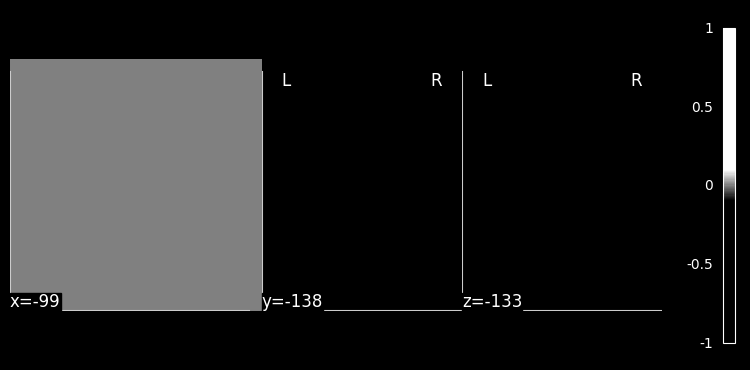

In [ ]:
npl.plot_anat(slope)

In [ ]:
av.avg_vol?

Signature:
av.avg_vol(
    subj_id,
    reference_img,
    results_path,
    image_suffix,
    subpath=None,
    input_suffix=None,
    tissue=None,
)
Docstring:
Inputs:
anat dir: participants file OR [(subj, week) and call it inside a loop].
Reference img (inside the Jupyter notebook loop for reading off the info file)
#week_path (path for each week's image), results_path (store results)
results path: directory to store results
subpath: path with the images, usually same as the reference image's parent folder
image suffix: suffix with which to save the slope and intercept images
    suggested: <image_type>_<space> where 'image_type' is "anat", "wm", "gm", etc; 'space' is native or template (<template_name>)
input_suffix: suffix for input image, if applicable (default = None) - if supplying, must being with "_"

Everything is done in the reference image. So this function will (...) (resample voxels in other weeks so that they are aligned with the reference, and perform multiple linear 

In [ ]:
nib.save(slope, 'temporary_img_trial.nii.gz')

So the issue when I tried to modularize the code (with the sufficient_weeks thing) is that it's not reading any of the images, I think.